In [1]:
import numpy as np
import astropy
import matplotlib
import matplotlib.pyplot as plt
from astropy.io import ascii
import matplotlib.cm as cm
import pandas as pd
from scipy import stats as ss
import re
import glob
import os
from scipy.interpolate import griddata
from matplotlib.ticker import FormatStrFormatter
import matplotlib.colors as colors
from ipywidgets import interact, FloatSlider
from ipywidgets import interact, SelectionSlider
from IPython.display import clear_output
from ipywidgets import interact, Dropdown
plt.rcParams['font.size'] =15
plt.rcParams['axes.labelsize'] =15
plt.rcParams['xtick.labelsize'] =15
plt.rcParams['ytick.labelsize'] =15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 5
plt.rcParams['ytick.major.width'] = 3
plt.rcParams['xtick.minor.width'] = 5
plt.rcParams['ytick.minor.width'] = 3

%matplotlib widget


## Load the Isochrone Data from Baraffe et al., (2002)

In [3]:
df=pd.read_csv('Table.csv')


df['Mass_J']= 1047*df['Mass']
df['Radius_J']= 11*df['Radius']
df.head()

,Teff,Lum,Mass,Radius,Age,Mass_J,Radius_J
0,628,-5.370,0.0005,0.176,1,0.5235,1.936
1,942,-4.715,0.0010,0.166,1,1.0470,1.826
2,1285,-4.137,0.0020,0.174,1,2.0940,1.914
3,1553,-3.746,0.0030,0.187,1,3.1410,2.057
4,1747,-3.482,0.0040,0.200,1,4.1880,2.200


# Basic H–R Diagram

## First show the raw stellar evolution tracks.

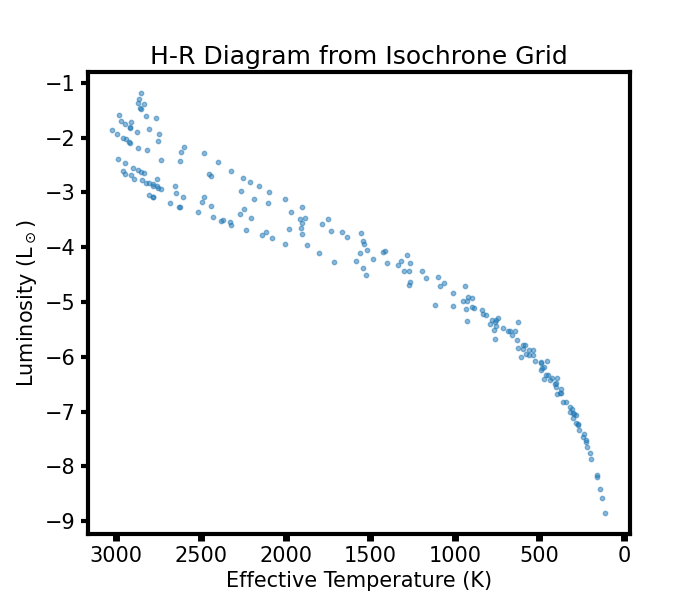

In [6]:
plt.figure(figsize=(7,6))

plt.scatter(df["Teff"], df["Lum"], s=10, alpha=0.5)

plt.gca().invert_xaxis()

plt.xlabel("Effective Temperature (K)")
plt.ylabel("Luminosity (L$_\\odot$)")
plt.title("H-R Diagram from Isochrone Grid")

plt.show()

# Select a Single Isochrone (Fixed Age)

## Students can explore how stellar properties change at a given age.

In [9]:
ages = np.sort(df["Age"].unique())

print("Available Ages:", ages)

Available Ages: [   1    5   10   50  100  120  500 1000 5000]


In [11]:
def plot_isochrone(age):

    subset = df[df["Age"] == age]

    plt.figure(figsize=(7,6))

    # full grid
    plt.scatter(
        df["Teff"],
        df["Lum"],
        color='lightgray',
        s=10,
        alpha=0.4,
        label="Model grid"
    )

    # selected isochrone
    sc = plt.scatter(
        subset["Teff"],
        subset["Lum"],
        c=subset["Mass_J"],
        cmap="viridis",
        s=50,
        edgecolor='black',
        label=f"Isochrone Age = {age} Myr"
    )

    plt.plot(
        subset["Teff"],
        subset["Lum"],
        color='red',
        linewidth=2
    )

    plt.colorbar(sc,label="Mass (M$_J$)")

    # HR diagram convention
    plt.gca().invert_xaxis()

    plt.xlabel("Effective Temperature (K)")
    plt.ylabel("Luminosity (L$_\\odot$)")
    plt.title("Interactive Isochrone Explorer")

    plt.legend()

    plt.show()

In [13]:
interact(
    plot_isochrone,
    age=SelectionSlider(
        options=ages,
        description="Age",
        continuous_update=False
    )
)

interactive(children=(SelectionSlider(continuous_update=False, description='Age', options=(1, 5, 10, 50, 100, …

<function __main__.plot_isochrone(age)>

# Explore Stellar Mass Evolution

## Students can see how a star evolves with time.

In [16]:
masses = np.sort(df["Mass_J"].unique())


def stellar_track(mass):

    clear_output(wait=True)

    subset = df[df["Mass_J"] == mass].sort_values("Age")

    fig, ax = plt.subplots(figsize=(7,6))

    # background grid
    ax.scatter(
        df["Teff"],
        df["Lum"],
        color="lightgray",
        s=10,
        alpha=0.4
    )

    # log normalization for age
    norm = colors.LogNorm(
        vmin=subset["Age"].min(),
        vmax=subset["Age"].max()
    )

    sc = ax.scatter(
        subset["Teff"],
        subset["Lum"],
        c=subset["Age"],
        cmap="plasma",
        norm=norm,
        s=60,
        edgecolor="black"
    )

    ax.plot(
        subset["Teff"],
        subset["Lum"],
        color="blue",
        lw=2
    )

    ax.invert_xaxis()

    ax.set_xlabel("Teff (K)")
    ax.set_ylabel("Luminosity (L$_\\odot$)")
    ax.set_title(f"Evolutionary Track: {mass:.2f} M$_J$")

    cbar = plt.colorbar(sc)
    cbar.set_label("Age (log scale)")

    plt.show()


interact(
    stellar_track,
    mass=SelectionSlider(
        options=masses,
        description="Mass",
        continuous_update=False
    )
)

interactive(children=(SelectionSlider(continuous_update=False, description='Mass', options=(0.5235, 1.047, 2.0…

<function __main__.stellar_track(mass)>

In [18]:


# Ensure Mass is in Jupiter units
if 'Mass_J' not in df.columns:
    df['Mass_J'] = df['Mass'] * 1000 

# Get unique discrete ages
unique_ages = np.sort(df['Age'].unique())

def plot_mass_radius(age):
    clear_output(wait=True)
    
    # Filter for the specific discrete isochrone
    subset = df[df["Age"] == age].sort_values("Mass_J")

    plt.figure(figsize=(8, 6))

    # --- Step 1: Full Grid (Faint Background) ---
    plt.scatter(
        df["Mass_J"],
        df["Radius_J"],
        color='lightgray',
        s=8,
        alpha=0.3,
        label="Full Model Grid"
    )

    # --- Step 2: Selected Isochrone Line ---
    plt.plot(
        subset["Mass_J"],
        subset["Radius_J"],
        color='red',
        linewidth=2,
        alpha=0.8,
        zorder=2
    )

    # --- Step 3: Selected Isochrone Points ---
    # Colored by Teff to show how temperature correlates with size/mass
    sc = plt.scatter(
        subset["Mass_J"],
        subset["Radius_J"],
        c=subset["Teff"], 
        cmap="magma",
        s=60,
        edgecolor='black',
        zorder=3,
        label=f"Age = {age} Myr"
    )

    # Colorbar management
    cbar = plt.colorbar(sc)
    cbar.set_label("Effective Temperature (K)")

    # --- Step 4: Formatting ---
    plt.xscale('log')
    plt.yscale('log')
    
    plt.xlabel("Mass ($M_J$)")
    plt.ylabel("Radius ($R_J$)")
    plt.title(f"Mass-Radius Isochrone: {age} Myr")
    
    plt.grid(True, which='both', linestyle=':', alpha=0.4)
    plt.legend()
    plt.show()

# 2. SelectionSlider for discrete age values
interact(
    plot_mass_radius,
    age=SelectionSlider(
        options=unique_ages,
        value=unique_ages[0],
        description='Age (Myr)',
        continuous_update=False
    )
)

interactive(children=(SelectionSlider(continuous_update=False, description='Age (Myr)', options=(1, 5, 10, 50,…

<function __main__.plot_mass_radius(age)>

In [20]:


# ======================
# Magnetic field models
# ======================
def Bdyn(M,L,R):
    kappa = M*L*L/(R**7)
    return 4800*(kappa**(1/6))

def Bdip(M,L,R):
    B = Bdyn(M,L,R)
    kappa2 = (1-(0.17/(M*1000)))**3
    return B*kappa2/2.83

# ======================
# Cyclotron frequency
# ======================
def B2F(B):
    return 2.8*B

def F2B(f):
    return f/2.8

# available masses
masses = np.sort(df["Mass"].unique())

# create slider options as (label, value) pairs
# label displayed in MJ, value used for computation
mass_options = [(f"{m*1000:.0f} M_J", m) for m in masses]

# ======================
# Interactive plotting
# ======================
def magnetic_evolution(selected_mass):
    
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(8,8))
    
    # --- Plot all masses faintly in background ---
    for m in masses:
        subset_bg = df[df["Mass"] == m].sort_values("Age")
        age_bg = subset_bg["Age"]
        lum_bg = 10**subset_bg["Lum"]
        radius_bg = subset_bg["Radius"]
        B_bg = Bdip(subset_bg["Mass"], lum_bg, radius_bg)
        ax1.plot(age_bg, B_bg, color="lightgray", lw=2, alpha=0.5)
    
    # --- Highlight selected mass ---
    subset = df[df["Mass"] == selected_mass].sort_values("Age")
    age = subset["Age"]
    lum = 10**subset["Lum"]
    radius = subset["Radius"]
    B = Bdip(subset["Mass"], lum, radius)
    
    sc = ax1.scatter(age, B, c=age, cmap="jet", s=120, edgecolor="black")
    ax1.plot(age, B, '--o', color="k", lw=2, label=f"{selected_mass*1000:.0f} $M_J$",ms=5)
    
    # --- Log scales and labels ---
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Age (Myr)")
    ax1.set_ylabel("Dipolar Magnetic Field (G)")
    ax1.set_title("Magnetic Field Evolution")
    
    # --- Secondary axis for cyclotron frequency ---
    secax = ax1.secondary_yaxis('right', functions=(B2F, F2B))
    secax.set_ylabel("Cyclotron Frequency (MHz)")
    
    #plt.colorbar(sc, label="Age (Myr)")
    ax1.legend()
    ax1.set_xlim(2, 3000)
    
    plt.show()

# ======================
# Slider for interactive mass selection (display in M_J)
# ======================
interact(
    magnetic_evolution,
    selected_mass=SelectionSlider(
        options=mass_options,
        description="Mass",
        continuous_update=False
    )
)

interactive(children=(SelectionSlider(continuous_update=False, description='Mass', options=(('0 M_J', 0.0005),…

<function __main__.magnetic_evolution(selected_mass)>

<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_98699/3699775720.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log (L/L$_\odot$)')
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_98699/3699775720.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots(figsize=(8,8))


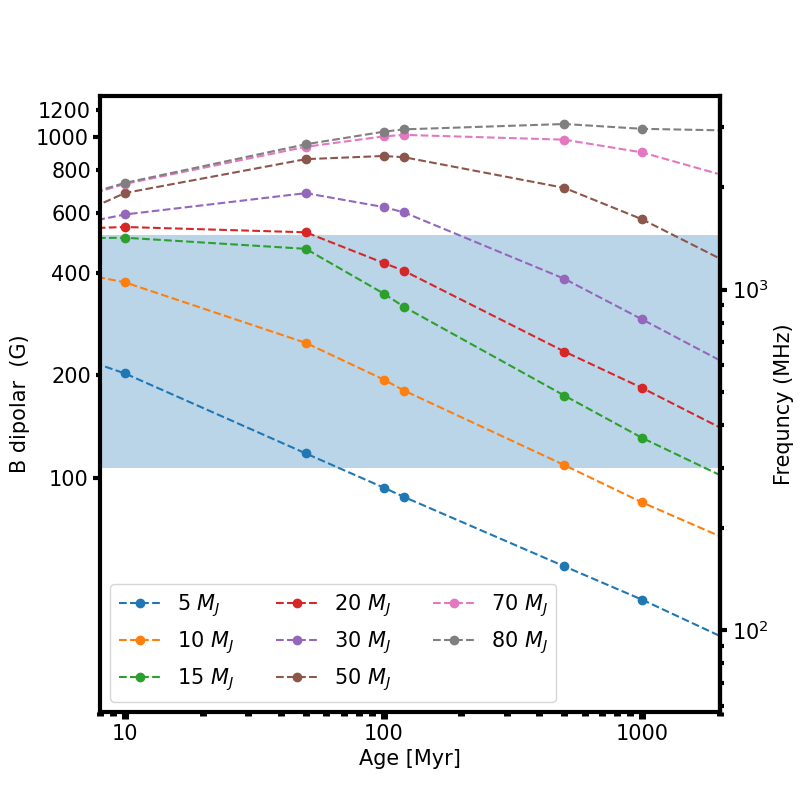

In [22]:

def Bdyn(M,L,R):
    kappa = M*L*L/(R**7)
    
    return 4800 * (kappa**(1/6)) 



def Bdip(M,L,R):
    B =Bdyn(M,L,R)
    
    kappa2=(1-(0.17/(M*1000)))**3
    
    return B*kappa2/2.83

m=df['Mass'] ==0.01
m2=df['Mass'] ==0.02
m3=df['Mass'] ==0.03
m4=df['Mass'] ==0.015
m5=df['Mass'] ==0.005
m6=df['Mass'] ==0.05
m7=df['Mass'] ==0.07
m8=df['Mass'] ==0.08


plt.plot(df['Age'][m3],df['Lum'][m3],'--o',label='1 $M_J$')
plt.plot(df['Age'][m4],df['Lum'][m4],'--o',label='5 $M_J$')
plt.plot(df['Age'][m],df['Lum'][m],'--o',label='10 $M_J$')
plt.plot(df['Age'][m2],df['Lum'][m2],'--o',label='20 $M_J$')
plt.plot(df['Age'][m6],df['Lum'][m6],'--o',label='20 $M_J$')

plt.xlabel('Age [Myr]')
plt.ylabel('log (L/L$_\odot$)')

plt.legend()

#%%


from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

fig, ax1 = plt.subplots(figsize=(8,8))


plt.plot(df['Age'][m5],Bdip(df['Mass'][m5],10**df['Lum'][m5]\
                            ,df['Radius'][m5]),'--o',label='5 $M_J$')

    

    
    
    
plt.plot(df['Age'][m],Bdip(df['Mass'][m],10**df['Lum'][m]\
                            ,df['Radius'][m]),'--o',label='10 $M_J$')
    
    



plt.plot(df['Age'][m4],Bdip(df['Mass'][m4],10**df['Lum'][m4]\
                            ,df['Radius'][m4]),'--o',label='15 $M_J$')

plt.plot(df['Age'][m2],Bdip(df['Mass'][m2],10**df['Lum'][m2]\
                            ,df['Radius'][m2]),'--o',label='20 $M_J$')
    
plt.plot(df['Age'][m3],Bdip(df['Mass'][m3],10**df['Lum'][m3]\
                            ,df['Radius'][m3]),'--o',label='30 $M_J$')
    
    
plt.plot(df['Age'][m6],Bdip(df['Mass'][m6],10**df['Lum'][m6]\
                            ,df['Radius'][m6]),'--o',label='50 $M_J$')
    
    
plt.plot(df['Age'][m7],Bdip(df['Mass'][m7],10**df['Lum'][m7]\
                            ,df['Radius'][m7]),'--o',label='70 $M_J$')
    
    
plt.plot(df['Age'][m8],Bdip(df['Mass'][m8],10**df['Lum'][m8]\
                            ,df['Radius'][m8]),'--o',label='80 $M_J$')
    

def B2F(x2):
    
    return 2.8*x2

def F2B(y):
    

    return y/2.8

secax=ax1.secondary_yaxis('right', functions=(B2F,F2B))


plt.xlabel('Age [Myr]')
plt.ylabel('B dipolar  (G)')

plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=3)


ax1.yaxis.set_minor_locator(MultipleLocator(200))
secax.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
secax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

secax.set_ylabel('Frequncy (MHz)')


xx=(22,22)
yy=(275,395)

#plt.scatter(xx,yy,c='k',s=150)

from matplotlib.patches import Rectangle

someX, someY = 5, 107
currentAxis = plt.gca()
currentAxis.add_patch(Rectangle((someX, someY), 2500, 410, fill='b', alpha=0.3))

plt.xlim(8,2000)

plt.savefig('Figure2.png')